Failed to read:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_30/rho_0.680/kT_0.860/nsteps_1000000/seed_1/randomization_log.hdf5
BlockingIOError(11, "Unable to synchronously open file (unable to lock file, errno = 11, error message = 'Resource temporarily unavailable')")
Logs found: 140
Usable rows: 137

Voxel phase-separated counts:
voxel_phase_separated
True     100
False     37
Name: count, dtype: int64

Summary by voxel phase-separated:


,count,mean,std,min,max
voxel_phase_separated,,,,,
False,37,0.000520,0.002204,-0.003658,0.006889
True,100,-0.767476,0.274471,-1.264849,-0.232222


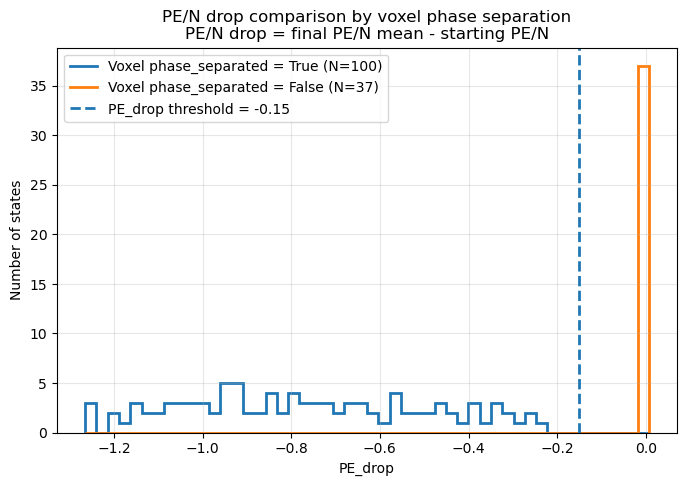

,n_fcc_cells,target_rho,kT,voxel_phase_separated,PE_drop,PE_drop_z_score,starting_PE_per_particle,last_PE_per_particle_mean,last_PE_per_particle_std,log_path
0,30.0,0.5,0.70,True,-1.254371,-278.857614,-3.860624,-5.114994,0.004498,/exp/e961/data/MDsims-data/pnichols/Thermalize...
1,30.0,0.5,0.72,True,-1.264849,-318.169737,-3.794837,-5.059686,0.003975,/exp/e961/data/MDsims-data/pnichols/Thermalize...
2,30.0,0.5,0.74,True,-1.247685,-285.343300,-3.726489,-4.974174,0.004373,/exp/e961/data/MDsims-data/pnichols/Thermalize...
3,30.0,0.5,0.76,True,-1.197813,-227.290027,-3.675390,-4.873203,0.005270,/exp/e961/data/MDsims-data/pnichols/Thermalize...
4,30.0,0.5,0.78,True,-1.142242,-239.291803,-3.633092,-4.775334,0.004773,/exp/e961/data/MDsims-data/pnichols/Thermalize...
...,...,...,...,...,...,...,...,...,...,...
132,30.0,0.8,0.76,False,0.000548,0.248336,-5.180533,-5.179984,0.002208,/exp/e961/data/MDsims-data/pnichols/Thermalize...
133,30.0,0.8,0.78,False,-0.001043,-0.460931,-5.159614,-5.160657,0.002264,/exp/e961/data/MDsims-data/pnichols/Thermalize...
134,30.0,0.8,0.80,False,-0.002230,-0.946537,-5.138730,-5.140960,0.002355,/exp/e961/data/MDsims-data/pnichols/Thermalize...
135,30.0,0.8,0.82,False,0.003408,1.529366,-5.125624,-5.122217,0.002228,/exp/e961/data/MDsims-data/pnichols/Thermalize...


In [7]:
# ============================================================
# Compare PE/N drop against voxel phase separation
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

import md_Helpers.Phase_Separation as ps
from md_Helpers.Project_Paths import THERMALIZED_STATES_V2_ROOT


# ============================================================
# Settings
# ============================================================

base_folder = THERMALIZED_STATES_V2_ROOT
phase_name = "randomization"

# Which PE-drop metadata value to histogram.
# Main choice:
#   "PE_drop" = last_PE_per_particle_mean - starting_PE_per_particle
#
# Other useful choices:
#   "PE_drop_z_score"
#   "last_PE_per_particle_mean"
#   "starting_PE_per_particle"
pe_quantity = "PE_drop"

n_hist_bins = 50


# ============================================================
# Helper functions
# ============================================================

def clean_bool(value):
    """
    Convert HDF5-ish bool values to real Python bool/None.
    """

    if value is None:
        return None

    if isinstance(value, bytes):
        value = value.decode()

    if hasattr(value, "item"):
        try:
            value = value.item()
        except Exception:
            pass

    if isinstance(value, bool):
        return value

    value_str = str(value).strip().lower()

    if value_str in ["true", "1", "yes"]:
        return True

    if value_str in ["false", "0", "no"]:
        return False

    return None


def clean_float(value):
    """
    Convert HDF5-ish values to float.
    """

    if value is None:
        return np.nan

    if isinstance(value, bytes):
        value = value.decode()

    if hasattr(value, "item"):
        try:
            value = value.item()
        except Exception:
            pass

    try:
        return float(value)
    except Exception:
        return np.nan


# ============================================================
# Collect data from all logs
# ============================================================

log_paths = sorted(
    Path(base_folder).glob(f"**/{phase_name}_log.hdf5")
)

rows = []

for log_path in log_paths:
    try:
        with h5py.File(log_path, mode="r") as hdf:
            if "metadata" not in hdf:
                continue

            metadata = hdf["metadata"]

            # ----------------------------------------------------
            # Basic metadata
            # ----------------------------------------------------
            attrs = metadata.attrs

            n_fcc_cells = clean_float(
                attrs.get("n_fcc_cells", np.nan)
            )

            target_rho = clean_float(
                attrs.get("target_rho", np.nan)
            )

            kT = clean_float(
                attrs.get("kT", np.nan)
            )

            # ----------------------------------------------------
            # Require phase_separation group
            # ----------------------------------------------------
            if "phase_separation" not in metadata:
                continue

            phase_group = metadata["phase_separation"]

            # ----------------------------------------------------
            # Voxel phase-separated result
            # ----------------------------------------------------
            if "voxel" not in phase_group:
                continue

            voxel_attrs = phase_group["voxel"].attrs

            voxel_phase_separated = clean_bool(
                voxel_attrs.get("phase_separated", None)
            )

            if voxel_phase_separated is None:
                continue

            # ----------------------------------------------------
            # PE-drop result
            # ----------------------------------------------------
            if "PE_drop" not in phase_group:
                continue

            PE_attrs = phase_group["PE_drop"].attrs

            pe_value = clean_float(
                PE_attrs.get(pe_quantity, np.nan)
            )

            if np.isnan(pe_value):
                continue

            rows.append({
                "n_fcc_cells": n_fcc_cells,
                "target_rho": target_rho,
                "kT": kT,

                "voxel_phase_separated": voxel_phase_separated,
                pe_quantity: pe_value,

                "PE_drop": clean_float(
                    PE_attrs.get("PE_drop", np.nan)
                ),
                "PE_drop_z_score": clean_float(
                    PE_attrs.get("PE_drop_z_score", np.nan)
                ),
                "starting_PE_per_particle": clean_float(
                    PE_attrs.get("starting_PE_per_particle", np.nan)
                ),
                "last_PE_per_particle_mean": clean_float(
                    PE_attrs.get("last_PE_per_particle_mean", np.nan)
                ),
                "last_PE_per_particle_std": clean_float(
                    PE_attrs.get("last_PE_per_particle_std", np.nan)
                ),

                "log_path": str(log_path),
            })

    except Exception as error:
        print("Failed to read:")
        print(log_path)
        print(repr(error))


df_compare = pd.DataFrame(rows)

print("Logs found:", len(log_paths))
print("Usable rows:", len(df_compare))

if len(df_compare) == 0:
    raise RuntimeError(
        "No usable rows found. Make sure voxel and PE_drop metadata "
        "have both been written."
    )


# ============================================================
# Split by voxel phase separation
# ============================================================

df_voxel_true = df_compare[
    df_compare["voxel_phase_separated"] == True
].copy()

df_voxel_false = df_compare[
    df_compare["voxel_phase_separated"] == False
].copy()

values_true = df_voxel_true[pe_quantity].to_numpy(dtype=float)
values_false = df_voxel_false[pe_quantity].to_numpy(dtype=float)

all_values = df_compare[pe_quantity].to_numpy(dtype=float)

print("\nVoxel phase-separated counts:")
print(df_compare["voxel_phase_separated"].value_counts(dropna=False))

print("\nSummary by voxel phase-separated:")
display(
    df_compare
    .groupby("voxel_phase_separated")[pe_quantity]
    .agg(["count", "mean", "std", "min", "max"])
)


# ============================================================
# Shared bin edges
# ============================================================

bin_edges = np.histogram_bin_edges(
    all_values,
    bins=n_hist_bins,
)

hist_true, _ = np.histogram(
    values_true,
    bins=bin_edges,
)

hist_false, _ = np.histogram(
    values_false,
    bins=bin_edges,
)


# ============================================================
# Plot shared-bin histograms
# ============================================================

plt.figure(figsize=(8, 5))

plt.stairs(
    hist_true,
    bin_edges,
    linewidth=2,
    label=f"Voxel phase_separated = True (N={len(values_true)})",
)

plt.stairs(
    hist_false,
    bin_edges,
    linewidth=2,
    label=f"Voxel phase_separated = False (N={len(values_false)})",
)

plt.axvline(
    ps.DEFAULT_PHASE_SEP_PE_DROP_THRESHOLD,
    linestyle="--",
    linewidth=2,
    label=f"PE_drop threshold = {ps.DEFAULT_PHASE_SEP_PE_DROP_THRESHOLD}",
)

plt.xlabel(pe_quantity)
plt.ylabel("Number of states")

if pe_quantity == "PE_drop":
    title_quantity = "PE/N drop = final PE/N mean - starting PE/N"
else:
    title_quantity = pe_quantity

plt.title(
    "PE/N drop comparison by voxel phase separation\n"
    + title_quantity
)

plt.grid(alpha=0.3)
plt.legend()
plt.show()


# ============================================================
# Optional: show the dataframe used
# ============================================================

df_compare

Failed to read:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_30/rho_0.680/kT_0.860/nsteps_1000000/seed_1/randomization_log.hdf5
BlockingIOError(11, "Unable to synchronously open file (unable to lock file, errno = 11, error message = 'Resource temporarily unavailable')")
Logs found: 140
Usable rows: 137

Voxel phase-separated counts:
voxel_phase_separated
True     100
False     37
Name: count, dtype: int64

Summary by voxel phase-separated:


,count,mean,std,min,max
voxel_phase_separated,,,,,
False,37,0.200731,0.990718,-1.794903,2.507528
True,100,-160.790322,63.643105,-318.169737,-43.497412


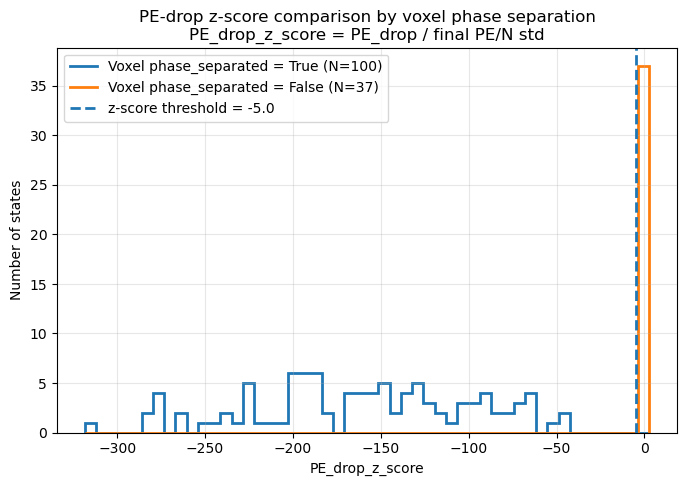

,n_fcc_cells,target_rho,kT,voxel_phase_separated,PE_drop_z_score,PE_drop,starting_PE_per_particle,last_PE_per_particle_mean,last_PE_per_particle_std,log_path
0,30.0,0.5,0.70,True,-278.857614,-1.254371,-3.860624,-5.114994,0.004498,/exp/e961/data/MDsims-data/pnichols/Thermalize...
1,30.0,0.5,0.72,True,-318.169737,-1.264849,-3.794837,-5.059686,0.003975,/exp/e961/data/MDsims-data/pnichols/Thermalize...
2,30.0,0.5,0.74,True,-285.343300,-1.247685,-3.726489,-4.974174,0.004373,/exp/e961/data/MDsims-data/pnichols/Thermalize...
3,30.0,0.5,0.76,True,-227.290027,-1.197813,-3.675390,-4.873203,0.005270,/exp/e961/data/MDsims-data/pnichols/Thermalize...
4,30.0,0.5,0.78,True,-239.291803,-1.142242,-3.633092,-4.775334,0.004773,/exp/e961/data/MDsims-data/pnichols/Thermalize...
...,...,...,...,...,...,...,...,...,...,...
132,30.0,0.8,0.76,False,0.248336,0.000548,-5.180533,-5.179984,0.002208,/exp/e961/data/MDsims-data/pnichols/Thermalize...
133,30.0,0.8,0.78,False,-0.460931,-0.001043,-5.159614,-5.160657,0.002264,/exp/e961/data/MDsims-data/pnichols/Thermalize...
134,30.0,0.8,0.80,False,-0.946537,-0.002230,-5.138730,-5.140960,0.002355,/exp/e961/data/MDsims-data/pnichols/Thermalize...
135,30.0,0.8,0.82,False,1.529366,0.003408,-5.125624,-5.122217,0.002228,/exp/e961/data/MDsims-data/pnichols/Thermalize...


In [4]:
# ============================================================
# Compare PE-drop z score against voxel phase separation
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

import md_Helpers.Phase_Separation as ps
from md_Helpers.Project_Paths import THERMALIZED_STATES_V2_ROOT


# ============================================================
# Settings
# ============================================================

base_folder = THERMALIZED_STATES_V2_ROOT
phase_name = "randomization"

# Histogram the PE-drop z score:
#   PE_drop_z_score = PE_drop / last_PE_per_particle_std
#
# Since:
#   PE_drop = final PE/N mean - starting PE/N
#
# a real PE/N drop gives a negative z score.
pe_quantity = "PE_drop_z_score"

n_hist_bins = 50


# ============================================================
# Helper functions
# ============================================================

def clean_bool(value):
    """
    Convert HDF5-ish bool values to real Python bool/None.
    """

    if value is None:
        return None

    if isinstance(value, bytes):
        value = value.decode()

    if hasattr(value, "item"):
        try:
            value = value.item()
        except Exception:
            pass

    if isinstance(value, bool):
        return value

    value_str = str(value).strip().lower()

    if value_str in ["true", "1", "yes"]:
        return True

    if value_str in ["false", "0", "no"]:
        return False

    return None


def clean_float(value):
    """
    Convert HDF5-ish values to float.
    """

    if value is None:
        return np.nan

    if isinstance(value, bytes):
        value = value.decode()

    if hasattr(value, "item"):
        try:
            value = value.item()
        except Exception:
            pass

    try:
        return float(value)
    except Exception:
        return np.nan


# ============================================================
# Collect data from all logs
# ============================================================

log_paths = sorted(
    Path(base_folder).glob(f"**/{phase_name}_log.hdf5")
)

rows = []

for log_path in log_paths:
    try:
        with h5py.File(log_path, mode="r") as hdf:
            if "metadata" not in hdf:
                continue

            metadata = hdf["metadata"]

            # ----------------------------------------------------
            # Basic metadata
            # ----------------------------------------------------
            attrs = metadata.attrs

            n_fcc_cells = clean_float(
                attrs.get("n_fcc_cells", np.nan)
            )

            target_rho = clean_float(
                attrs.get("target_rho", np.nan)
            )

            kT = clean_float(
                attrs.get("kT", np.nan)
            )

            # ----------------------------------------------------
            # Require phase_separation group
            # ----------------------------------------------------
            if "phase_separation" not in metadata:
                continue

            phase_group = metadata["phase_separation"]

            # ----------------------------------------------------
            # Voxel phase-separated result
            # ----------------------------------------------------
            if "voxel" not in phase_group:
                continue

            voxel_attrs = phase_group["voxel"].attrs

            voxel_phase_separated = clean_bool(
                voxel_attrs.get("phase_separated", None)
            )

            if voxel_phase_separated is None:
                continue

            # ----------------------------------------------------
            # PE-drop result
            # ----------------------------------------------------
            if "PE_drop" not in phase_group:
                continue

            PE_attrs = phase_group["PE_drop"].attrs

            pe_value = clean_float(
                PE_attrs.get(pe_quantity, np.nan)
            )

            if np.isnan(pe_value):
                continue

            rows.append({
                "n_fcc_cells": n_fcc_cells,
                "target_rho": target_rho,
                "kT": kT,

                "voxel_phase_separated": voxel_phase_separated,
                pe_quantity: pe_value,

                "PE_drop": clean_float(
                    PE_attrs.get("PE_drop", np.nan)
                ),
                "PE_drop_z_score": clean_float(
                    PE_attrs.get("PE_drop_z_score", np.nan)
                ),
                "starting_PE_per_particle": clean_float(
                    PE_attrs.get("starting_PE_per_particle", np.nan)
                ),
                "last_PE_per_particle_mean": clean_float(
                    PE_attrs.get("last_PE_per_particle_mean", np.nan)
                ),
                "last_PE_per_particle_std": clean_float(
                    PE_attrs.get("last_PE_per_particle_std", np.nan)
                ),

                "log_path": str(log_path),
            })

    except Exception as error:
        print("Failed to read:")
        print(log_path)
        print(repr(error))


df_compare = pd.DataFrame(rows)

print("Logs found:", len(log_paths))
print("Usable rows:", len(df_compare))

if len(df_compare) == 0:
    raise RuntimeError(
        "No usable rows found. Make sure voxel and PE_drop metadata "
        "have both been written."
    )


# ============================================================
# Split by voxel phase separation
# ============================================================

df_voxel_true = df_compare[
    df_compare["voxel_phase_separated"] == True
].copy()

df_voxel_false = df_compare[
    df_compare["voxel_phase_separated"] == False
].copy()

values_true = df_voxel_true[pe_quantity].to_numpy(dtype=float)
values_false = df_voxel_false[pe_quantity].to_numpy(dtype=float)

all_values = df_compare[pe_quantity].to_numpy(dtype=float)

print("\nVoxel phase-separated counts:")
print(df_compare["voxel_phase_separated"].value_counts(dropna=False))

print("\nSummary by voxel phase-separated:")
display(
    df_compare
    .groupby("voxel_phase_separated")[pe_quantity]
    .agg(["count", "mean", "std", "min", "max"])
)


# ============================================================
# Shared bin edges
# ============================================================

bin_edges = np.histogram_bin_edges(
    all_values,
    bins=n_hist_bins,
)

hist_true, _ = np.histogram(
    values_true,
    bins=bin_edges,
)

hist_false, _ = np.histogram(
    values_false,
    bins=bin_edges,
)


# ============================================================
# Plot shared-bin histograms
# ============================================================

plt.figure(figsize=(8, 5))

plt.stairs(
    hist_true,
    bin_edges,
    linewidth=2,
    label=f"Voxel phase_separated = True (N={len(values_true)})",
)

plt.stairs(
    hist_false,
    bin_edges,
    linewidth=2,
    label=f"Voxel phase_separated = False (N={len(values_false)})",
)

plt.axvline(
    -ps.DEFAULT_PHASE_SEP_PE_DROP_Z_LIMIT,
    linestyle="--",
    linewidth=2,
    label=f"z-score threshold = {-ps.DEFAULT_PHASE_SEP_PE_DROP_Z_LIMIT}",
)

plt.xlabel("PE_drop_z_score")
plt.ylabel("Number of states")

plt.title(
    "PE-drop z-score comparison by voxel phase separation\n"
    "PE_drop_z_score = PE_drop / final PE/N std"
)

plt.grid(alpha=0.3)
plt.legend()
plt.show()


# ============================================================
# Optional: show the dataframe used
# ============================================================

df_compare

Voxel phase_separated = False states: 37


count    37.000000
mean      0.200731
std       0.990718
min      -1.794903
max       2.507528
Name: PE_drop_z_score, dtype: float64

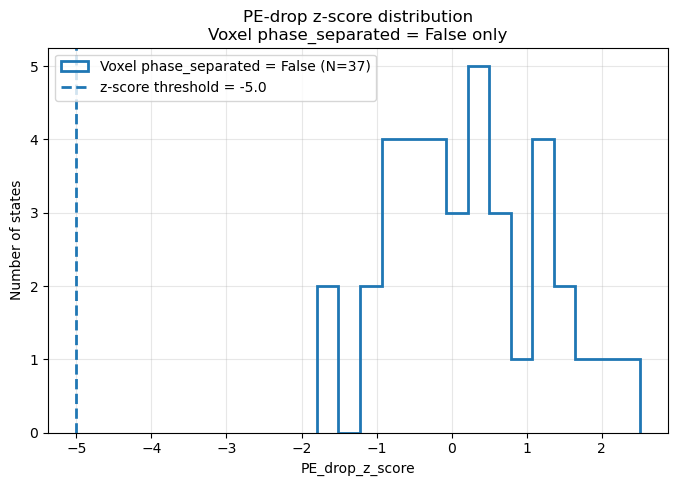

,n_fcc_cells,target_rho,kT,voxel_phase_separated,PE_drop,PE_drop_z_score,starting_PE_per_particle,last_PE_per_particle_mean,last_PE_per_particle_std,log_path
95,30.0,0.70,0.82,False,-0.002090,-0.975599,-4.506031,-4.508121,0.002142,/exp/e961/data/MDsims-data/pnichols/Thermalize...
96,30.0,0.70,0.84,False,-0.003162,-1.656632,-4.488877,-4.492040,0.001909,/exp/e961/data/MDsims-data/pnichols/Thermalize...
101,30.0,0.72,0.78,False,-0.001537,-0.717939,-4.663062,-4.664599,0.002141,/exp/e961/data/MDsims-data/pnichols/Thermalize...
102,30.0,0.72,0.80,False,0.000700,0.314732,-4.648293,-4.647593,0.002224,/exp/e961/data/MDsims-data/pnichols/Thermalize...
103,30.0,0.72,0.82,False,-0.000558,-0.292112,-4.631716,-4.632275,0.001911,/exp/e961/data/MDsims-data/pnichols/Thermalize...
104,30.0,0.72,0.84,False,0.000726,0.317531,-4.617330,-4.616604,0.002288,/exp/e961/data/MDsims-data/pnichols/Thermalize...
106,30.0,0.74,0.72,False,0.004086,1.990040,-4.845528,-4.841442,0.002053,/exp/e961/data/MDsims-data/pnichols/Thermalize...
107,30.0,0.74,0.74,False,-0.003658,-1.794903,-4.820476,-4.824134,0.002038,/exp/e961/data/MDsims-data/pnichols/Thermalize...
108,30.0,0.74,0.76,False,0.001621,0.712966,-4.808414,-4.806793,0.002274,/exp/e961/data/MDsims-data/pnichols/Thermalize...
109,30.0,0.74,0.78,False,0.002141,1.074111,-4.792305,-4.790164,0.001994,/exp/e961/data/MDsims-data/pnichols/Thermalize...


In [10]:
# ============================================================
# Histogram of PE-drop z score for voxel phase_separated = False only
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Quantity to plot
pe_quantity = "PE_drop_z_score"

# Keep only states that voxel method says are NOT phase separated
df_false_only = df_compare[
    df_compare["voxel_phase_separated"] == False
].copy()

values_false_only = df_false_only[pe_quantity].to_numpy(dtype=float)

values_false_only = values_false_only[
    np.isfinite(values_false_only)
]

print("Voxel phase_separated = False states:", len(values_false_only))

display(
    df_false_only[pe_quantity]
    .agg(["count", "mean", "std", "min", "max"])
)

# ============================================================
# Histogram
# ============================================================

n_hist_bins = 15

plt.figure(figsize=(8, 5))

plt.hist(
    values_false_only,
    bins=n_hist_bins,
    histtype="step",
    linewidth=2,
    label=f"Voxel phase_separated = False (N={len(values_false_only)})",
)

plt.axvline(
    -ps.DEFAULT_PHASE_SEP_PE_DROP_Z_LIMIT,
    linestyle="--",
    linewidth=2,
    label=f"z-score threshold = {-ps.DEFAULT_PHASE_SEP_PE_DROP_Z_LIMIT}",
)

plt.xlabel("PE_drop_z_score")
plt.ylabel("Number of states")
plt.title(
    "PE-drop z-score distribution\n"
    "Voxel phase_separated = False only"
)

plt.grid(alpha=0.3)
plt.legend()
plt.show()

df_false_only